In [9]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

In [10]:
SPHERE_WINDOW = dict(
    length_min=5, length_max=7,
    hydro_min=1.1988, hydro_max=2,
    q_min=-1, q_max=1,
    require_beta=False,
)

FIBER_WINDOW = dict(
    length_min=7, length_max=10,
    hydro_min=None, hydro_max=None,
    q_min=-1, q_max=1,
    require_beta=True,
)

In [11]:
def beta_flag(beta_sheet_fraction: float) -> bool:
    return (pd.notna(beta_sheet_fraction) and beta_sheet_fraction > 0.0)

In [12]:
FILE_MAP = [
    dict(name="PepMorph (sphere-targeted)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_spheres_final.txt", metrics_file="gen_peptides/spheres_metrics_merged.csv", target="spheres"),
    dict(name="PepMorph (fiber-targeted)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_fiber_final.txt", metrics_file="gen_peptides/fibers_metrics.csv", target="fibers"),

    dict(name="Random sampling (5-10 aa)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_random.txt", metrics_file="gen_peptides/random_metrics.csv", target="spheres"),
     dict(name="Random sampling (5-10 aa)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_random.txt", metrics_file="gen_peptides/random_metrics.csv", target="fibers"),
     dict(name="Random sampling (5-10 aa)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_random.txt", metrics_file="gen_peptides/random_metrics.csv", target="untargeted"),

    dict(name="Length-cond. unconditional (sphere lengths)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_random_spheres_final.txt", metrics_file="gen_peptides/spheres_metrics_unconditional.csv", target="spheres"),
    dict(name="Length-cond. unconditional (fiber lengths)", n_generated=4800,
         ap_file="gen_peptides/filtered_ap_peptides_random_fiber_final.txt", metrics_file="gen_peptides/fibers_metrics_unconditional.csv", target="fibers"),
]

In [13]:
def load_ap_pass_txt(path: str) -> pd.DataFrame:
    """
    Expected format:
    SEQ,LENGTH,AP,SA_prob
    """
    df = pd.read_csv(path, header=None, names=["sequence", "3-seq", "AP", "SA_prob"])
    df["sequence"] = df["sequence"].astype(str).str.strip()
    df["length"] = df["sequence"].str.len().astype(int)
    df["AP"] = df["AP"].astype(float)
    df["SA_prob"] = df["SA_prob"].astype(float)
    return df

def load_metrics_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Normalize expected columns
    if "sequence" not in df.columns:
        raise ValueError(f"{path} must contain a 'sequence' column")
    df["sequence"] = df["sequence"].astype(str).str.strip()
    df["length"] = df["sequence"].str.len().astype(int)

    # Some metrics CSVs have peptide_id; keep but not required
    for col in ["beta_sheet_fraction", "hydrophobic_moment", "net_charge"]:
        if col not in df.columns:
            df[col] = np.nan
    return df

def merge_ap_and_metrics(ap_df: pd.DataFrame, met_df: pd.DataFrame) -> pd.DataFrame:
    """
    Left-join so that AP-pass sequences without metrics are preserved (PEP-FOLD failure or missing).
    """
    m = ap_df.merge(met_df[["sequence", "beta_sheet_fraction", "hydrophobic_moment", "net_charge", "length"]],
                    on="sequence", how="left", suffixes=("", "_met"))

    m["has_beta"] = m["beta_sheet_fraction"].apply(beta_flag)
    return m

def passes_window(row: pd.Series, window: dict) -> bool:
    """
    Proxy-descriptor feasibility for a target.
    If metrics are missing (NaN), it cannot pass.
    """
    # Enforce length window (critical!)
    if "length_min" in window and row["length"] < window["length_min"]:
        return False
    if "length_max" in window and row["length"] > window["length_max"]:
        return False

    # Require PEP-FOLD metrics to exist for any check beyond length.
    if pd.isna(row["net_charge"]) or pd.isna(row["hydrophobic_moment"]) or pd.isna(row["beta_sheet_fraction"]):
        return False

    if window.get("require_beta", False) and (row["has_beta"] is not True):
        return False

    # Net charge window
    if window["q_min"] is not None and not (window["q_min"] <= float(row["net_charge"]) <= window["q_max"]):
        return False

    # Hydrophobic moment window (only for spheres)
    if window["hydro_min"] is not None and not (window["hydro_min"] <= float(row["hydrophobic_moment"]) <= window["hydro_max"]):
        return False

    return True

def bootstrap_permutation_curves(hit_flags: np.ndarray,
                                 score: np.ndarray | None = None,
                                 n_boot: int = 800,
                                 seed: int = 0):
    """
    Order-free sample-efficiency curves via random permutation bootstrap.

    hit_flags: 0/1 per oracle call
    score: optional scalar per call (e.g., AP), used to compute running max among hits.
           Non-hits should have score = -inf if you want "best among hits".
    Returns:
      budgets (1..N),
      mean_hits, lo_hits, hi_hits,
      (optional) mean_best, lo_best, hi_best
    """
    rng = np.random.default_rng(seed)
    n = len(hit_flags)
    budgets = np.arange(1, n + 1)

    hits_mat = np.zeros((n_boot, n), dtype=float)
    best_mat = np.zeros((n_boot, n), dtype=float) if score is not None else None

    for b in range(n_boot):
        perm = rng.permutation(n)
        h = hit_flags[perm].astype(int)
        hits_mat[b] = np.cumsum(h)

        if score is not None:
            s = score[perm].astype(float)
            # running max of score among hits: treat non-hits as -inf
            # ensure -inf stays -inf until first hit
            runmax = np.maximum.accumulate(s)
            best_mat[b] = runmax

    mean_hits = hits_mat.mean(axis=0)
    lo_hits = np.percentile(hits_mat, 2.5, axis=0)
    hi_hits = np.percentile(hits_mat, 97.5, axis=0)

    if best_mat is None:
        return budgets, mean_hits, lo_hits, hi_hits, None
    else:
        mean_best = best_mat.mean(axis=0)
        lo_best = np.percentile(best_mat, 2.5, axis=0)
        hi_best = np.percentile(best_mat, 97.5, axis=0)
        return budgets, mean_hits, lo_hits, hi_hits, (mean_best, lo_best, hi_best)

def wilson_ci(k: int, n: int, z: float = 1.96):
    """
    Wilson score interval for binomial proportion.
    Returns (lo, hi). If n==0, returns (nan, nan).
    """
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))

In [14]:
def pepfold_efficiency_for_entry(entry: dict) -> dict:
    ap = load_ap_pass_txt(entry["ap_file"])
    met = load_metrics_csv(entry["metrics_file"])
    merged = merge_ap_and_metrics(ap, met)

    # Define target window (or none)
    target = entry["target"]
    if target == "spheres":
        window = SPHERE_WINDOW
    elif target == "fibers":
        window = FIBER_WINDOW
    elif target == "untargeted":
        window = None
    else:
        raise ValueError(f"Unknown target: {target}")

    # Oracle calls for PEP-FOLD stage = number of AP-pass sequences attempted
    n_oracle_calls = len(merged)

    # PEP-FOLD "success" = metrics exist (not NaN)
    pepfold_success = merged["beta_sheet_fraction"].notna().sum()

    if window is None:
        merged["proxy_hit"] = False
    else:
        merged["proxy_hit"] = merged.apply(lambda r: passes_window(r, window), axis=1)

    n_hits = int(merged["proxy_hit"].sum())

    # Score curve: best AP among hits. Non-hits = -inf.
    score = merged["AP"].to_numpy().astype(float)
    score_best_among_hits = np.where(merged["proxy_hit"].to_numpy(), score, -np.inf)

    out = dict(
        name=entry["name"],
        target=target,
        n_generated=entry["n_generated"],
        n_ap_pass=n_oracle_calls,
        n_pepfold_success=int(pepfold_success),
        n_proxy_hits=n_hits,
        data=merged,
        score_best_among_hits=score_best_among_hits,
    )
    return out

In [15]:
pepfold_results = []
for e in FILE_MAP:
    if not (Path(e["ap_file"]).exists() and Path(e["metrics_file"]).exists()):
        print(f"Skipping (missing files): {e['name']}")
        continue
    pepfold_results.append(pepfold_efficiency_for_entry(e))

len(pepfold_results), [r["name"] for r in pepfold_results]

(7,
 ['PepMorph (sphere-targeted)',
  'PepMorph (fiber-targeted)',
  'Random sampling (5-10 aa)',
  'Random sampling (5-10 aa)',
  'Random sampling (5-10 aa)',
  'Length-cond. unconditional (sphere lengths)',
  'Length-cond. unconditional (fiber lengths)'])

In [16]:
rows = []
for r in pepfold_results:
    n_gen = r["n_generated"]
    n_ap = r["n_ap_pass"]
    n_pf = r["n_pepfold_success"]
    n_hit = r["n_proxy_hits"]

    # hit rate per PEP-FOLD call (conservative includes PEP-FOLD failures)
    p = (n_hit / n_ap) if n_ap > 0 else np.nan
    lo, hi = wilson_ci(n_hit, n_ap) if n_ap > 0 else (np.nan, np.nan)

    calls_per_hit = (1 / p) if (p and p > 0) else np.inf
    calls_per_hit_lo = (1 / hi) if (hi and hi > 0) else np.inf
    calls_per_hit_hi = (1 / lo) if (lo and lo > 0) else np.inf

    rows.append(dict(
        cohort=r["name"],
        target=r["target"],
        generated=n_gen,
        ap_pass=n_ap,
        pepfold_success=n_pf,
        proxy_hits=n_hit,
        hit_rate=p,
        hit_rate_ci_lo=lo,
        hit_rate_ci_hi=hi,
        calls_per_hit=calls_per_hit,
        calls_per_hit_ci_lo=calls_per_hit_lo,
        calls_per_hit_ci_hi=calls_per_hit_hi
    ))

pepfold_summary = pd.DataFrame(rows)
pepfold_summary.to_csv("pepfold_efficiency_summary.csv", index=False)
pepfold_summary

,cohort,target,generated,ap_pass,pepfold_success,proxy_hits,hit_rate,hit_rate_ci_lo,hit_rate_ci_hi,calls_per_hit,calls_per_hit_ci_lo,calls_per_hit_ci_hi
0,PepMorph (sphere-targeted),spheres,4800,4173,4173,76,0.018212,1.457599e-02,0.022735,54.907895,43.985281,6.860596e+01
1,PepMorph (fiber-targeted),fibers,4800,3794,3794,29,0.007644,5.327312e-03,0.010956,130.827586,91.273835,1.877119e+02
2,Random sampling (5-10 aa),spheres,4800,1863,1611,0,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18
3,Random sampling (5-10 aa),fibers,4800,1863,1611,4,0.002147,8.352489e-04,0.005508,465.750000,181.558356,1.197248e+03
4,Random sampling (5-10 aa),untargeted,4800,1863,1611,0,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18
5,Length-cond. unconditional (sphere lengths),spheres,4800,2566,2566,3,0.001169,3.976820e-04,0.003432,855.333333,291.377809,2.514572e+03
6,Length-cond. unconditional (fiber lengths),fibers,4800,2043,2043,7,0.003426,1.660684e-03,0.007056,291.857143,141.724062,6.021614e+02


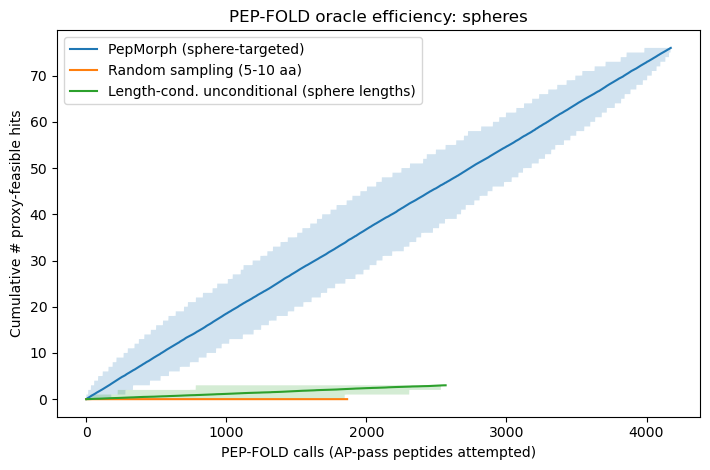

Wrote pepfold_hits_vs_calls_{target}.pdf


/home/go46vuw/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/go46vuw/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:4657: RuntimeWarning: invalid value encountered in add
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))


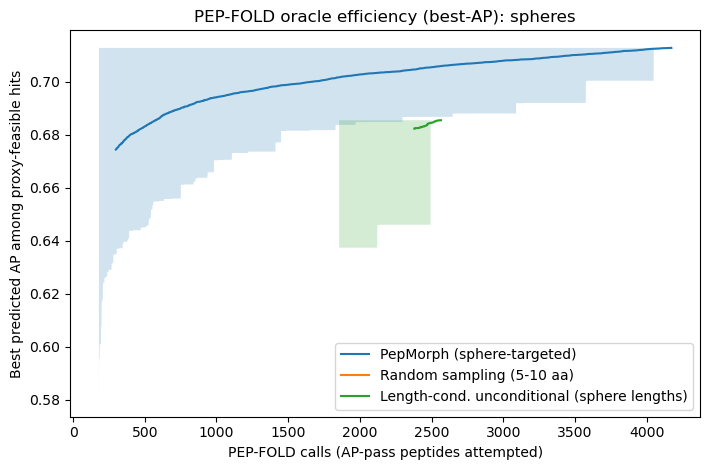

Wrote pepfold_bestAP_vs_calls_spheres.pdf


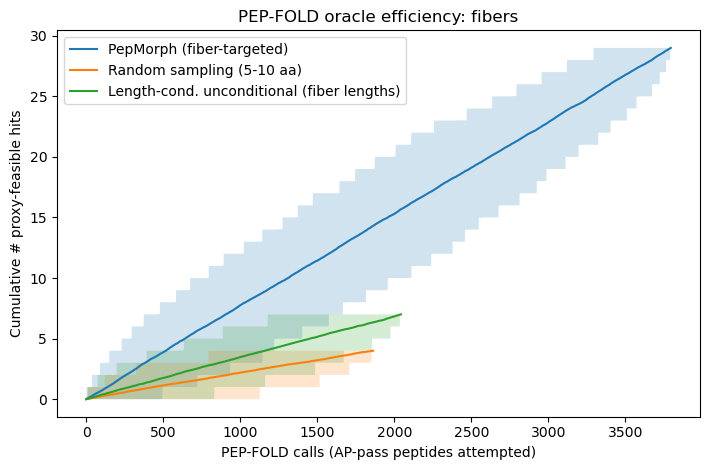

Wrote pepfold_hits_vs_calls_{target}.pdf


/home/go46vuw/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/go46vuw/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:4657: RuntimeWarning: invalid value encountered in add
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))


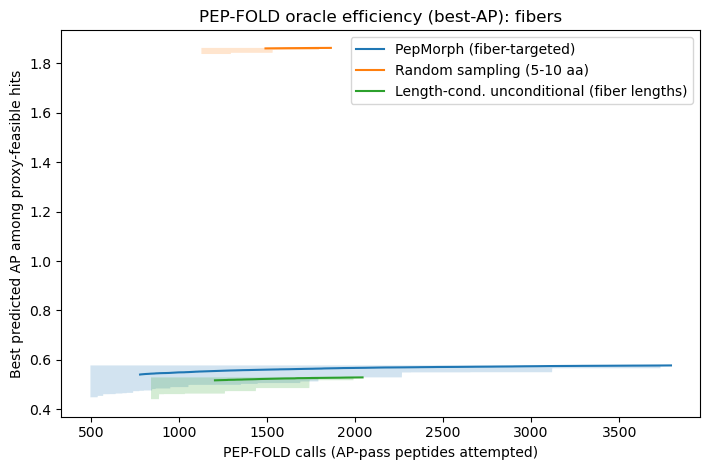

Wrote pepfold_bestAP_vs_calls_fibers.pdf


In [17]:
def plot_pepfold_curves(target: str, include_names: list[str] | None = None):
    """
    Plots cumulative proxy-hits vs PEP-FOLD calls for all cohorts of a given target.
    Also plots best AP among hits vs calls.
    """
    subset = [r for r in pepfold_results if r["target"] == target]
    if include_names is not None:
        subset = [r for r in subset if r["name"] in include_names]

    if len(subset) == 0:
        print("No cohorts for target:", target)
        return

    # --- Plot 1: cumulative hits vs oracle calls ---
    plt.figure(figsize=(7.2, 4.8))
    for r in subset:
        d = r["data"]
        hit = d["proxy_hit"].to_numpy().astype(int)
        budgets, m, lo, hi, _ = bootstrap_permutation_curves(hit, score=None, n_boot=600, seed=GLOBAL_SEED)
        plt.plot(budgets, m, label=r["name"])
        plt.fill_between(budgets, lo, hi, alpha=0.2)

    plt.xlabel("PEP-FOLD calls (AP-pass peptides attempted)")
    plt.ylabel("Cumulative # proxy-feasible hits")
    plt.title(f"PEP-FOLD oracle efficiency: {target}")
    plt.legend(frameon=True)
    plt.tight_layout()
    out1 = "pepfold_hits_vs_calls_{target}.pdf"
    plt.savefig(out1)
    plt.show()
    plt.close()
    print("Wrote", out1)

    # --- Plot 2: best AP among hits vs oracle calls ---
    plt.figure(figsize=(7.2, 4.8))
    for r in subset:
        d = r["data"]
        hit = d["proxy_hit"].to_numpy().astype(int)

        # best-AP curve among hits
        score = r["score_best_among_hits"]
        budgets, m_hits, _, _, best = bootstrap_permutation_curves(hit, score=score, n_boot=600, seed=GLOBAL_SEED)
        mean_best, lo_best, hi_best = best

        # Replace -inf (no hit yet) with NaN so the curve doesn't drop the axis
        mean_best = np.where(np.isfinite(mean_best), mean_best, np.nan)
        lo_best = np.where(np.isfinite(lo_best), lo_best, np.nan)
        hi_best = np.where(np.isfinite(hi_best), hi_best, np.nan)

        plt.plot(budgets, mean_best, label=r["name"])
        plt.fill_between(budgets, lo_best, hi_best, alpha=0.2)

    plt.xlabel("PEP-FOLD calls (AP-pass peptides attempted)")
    plt.ylabel("Best predicted AP among proxy-feasible hits")
    plt.title(f"PEP-FOLD oracle efficiency (best-AP): {target}")
    plt.legend(frameon=True)
    plt.tight_layout()
    out2 = f"pepfold_bestAP_vs_calls_{target}.pdf"
    plt.savefig(out2)
    plt.show()
    plt.close()
    print("Wrote", out2)

plot_pepfold_curves("spheres")
plot_pepfold_curves("fibers")

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path

# ---------- paper style ----------
rcParams["font.family"] = "Lato"
rcParams["font.size"] = 16
rcParams["text.color"] = "#3F3F3F"
rcParams["axes.labelcolor"] = "#3F3F3F"
rcParams["xtick.color"] = "#3F3F3F"
rcParams["ytick.color"] = "#3F3F3F"

TEAL = ["#b5d1ae", "#80ae9a", "#568b87", "#326b77", "#1b485e", "#122740"]

def _clean_axes(ax):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

def wilson_ci(k: int, n: int, z: float = 1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))

def prob_at_least_one_hit(p: float, n: np.ndarray) -> np.ndarray:
    # stable for small p: 1 - (1-p)^n
    return 1.0 - np.power(1.0 - p, n)

pepfold_summary["cohort"] = pepfold_summary["cohort"].astype(str)
pepfold_summary["target"] = pepfold_summary["target"].astype(str)

pepfold_summary


,cohort,target,generated,ap_pass,pepfold_success,proxy_hits,hit_rate,hit_rate_ci_lo,hit_rate_ci_hi,calls_per_hit,calls_per_hit_ci_lo,calls_per_hit_ci_hi
0,PepMorph (sphere-targeted),spheres,4800,4173,4173,76,0.018212,1.457599e-02,0.022735,54.907895,43.985281,6.860596e+01
1,PepMorph (fiber-targeted),fibers,4800,3794,3794,29,0.007644,5.327312e-03,0.010956,130.827586,91.273835,1.877119e+02
2,Random sampling (5-10 aa),spheres,4800,1863,1611,0,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18
3,Random sampling (5-10 aa),fibers,4800,1863,1611,4,0.002147,8.352489e-04,0.005508,465.750000,181.558356,1.197248e+03
4,Random sampling (5-10 aa),untargeted,4800,1863,1611,0,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18
5,Length-cond. unconditional (sphere lengths),spheres,4800,2566,2566,3,0.001169,3.976820e-04,0.003432,855.333333,291.377809,2.514572e+03
6,Length-cond. unconditional (fiber lengths),fibers,4800,2043,2043,7,0.003426,1.660684e-03,0.007056,291.857143,141.724062,6.021614e+02


In [19]:
df = pepfold_summary.copy()

df["hit_rate_gen"] = df["proxy_hits"] / df["generated"]

ci_gen = df.apply(lambda r: wilson_ci(int(r["proxy_hits"]), int(r["generated"])), axis=1)
df["hit_rate_gen_ci_lo"] = [c[0] for c in ci_gen]
df["hit_rate_gen_ci_hi"] = [c[1] for c in ci_gen]

df["calls_per_hit_gen"] = np.where(df["hit_rate_gen"] > 0, 1.0 / df["hit_rate_gen"], np.inf)
df["calls_per_hit_gen_ci_lo"] = np.where(df["hit_rate_gen_ci_hi"] > 0, 1.0 / df["hit_rate_gen_ci_hi"], np.inf)
df["calls_per_hit_gen_ci_hi"] = np.where(df["hit_rate_gen_ci_lo"] > 0, 1.0 / df["hit_rate_gen_ci_lo"], np.inf)

df.to_csv("pepfold_efficiency_summary_augmented.csv", index=False)
df

,cohort,target,generated,ap_pass,pepfold_success,proxy_hits,hit_rate,hit_rate_ci_lo,hit_rate_ci_hi,calls_per_hit,calls_per_hit_ci_lo,calls_per_hit_ci_hi,hit_rate_gen,hit_rate_gen_ci_lo,hit_rate_gen_ci_hi,calls_per_hit_gen,calls_per_hit_gen_ci_lo,calls_per_hit_gen_ci_hi
0,PepMorph (sphere-targeted),spheres,4800,4173,4173,76,0.018212,1.457599e-02,0.022735,54.907895,43.985281,6.860596e+01,0.015833,0.012669,0.019772,63.157895,50.577214,78.931041
1,PepMorph (fiber-targeted),fibers,4800,3794,3794,29,0.007644,5.327312e-03,0.010956,130.827586,91.273835,1.877119e+02,0.006042,0.004210,0.008663,165.517241,115.427963,237.532418
2,Random sampling (5-10 aa),spheres,4800,1863,1611,0,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18,0.000000,0.000000,0.000800,inf,1250.479384,inf
3,Random sampling (5-10 aa),fibers,4800,1863,1611,4,0.002147,8.352489e-04,0.005508,465.750000,181.558356,1.197248e+03,0.000833,0.000324,0.002141,1200.000000,467.089108,3085.390892
4,Random sampling (5-10 aa),untargeted,4800,1863,1611,0,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18,0.000000,0.000000,0.000800,inf,1250.479384,inf
5,Length-cond. unconditional (sphere lengths),spheres,4800,2566,2566,3,0.001169,3.976820e-04,0.003432,855.333333,291.377809,2.514572e+03,0.000625,0.000213,0.001836,1600.000000,544.627043,4704.226291
6,Length-cond. unconditional (fiber lengths),fibers,4800,2043,2043,7,0.003426,1.660684e-03,0.007056,291.857143,141.724062,6.021614e+02,0.001458,0.000707,0.003007,685.714286,332.509468,1415.239103


/tmp/ipykernel_2769476/737739301.py:23: RuntimeWarning: invalid value encountered in subtract
  yerr = np.vstack([y - lo, hi - y])


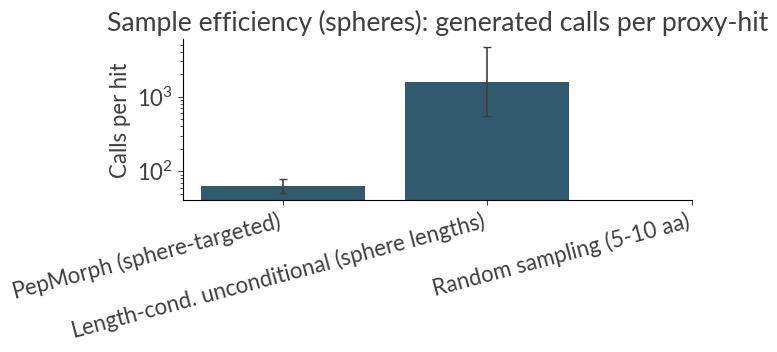

Wrote calls_per_hit_gen_spheres.pdf


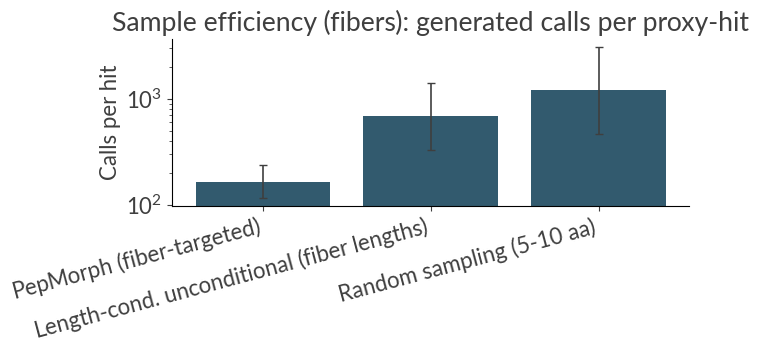

Wrote calls_per_hit_gen_fibers.pdf


In [20]:
# %% [markdown]
# ## Plot: calls-per-hit (generated-sample budget) with Wilson CI
# Recommendation: show only targeted cohorts in main text; keep full set in SI.

# %%
def plot_calls_per_hit_bar(df: pd.DataFrame,
                           target: str,
                           metric: str,
                           title: str,
                           outfile: str,
                           cohort_order: list[str] | None = None,
                           logy: bool = True):
    d = df[df["target"] == target].copy()
    if cohort_order is not None:
        d["cohort"] = pd.Categorical(d["cohort"], categories=cohort_order, ordered=True)
        d = d.sort_values("cohort")

    y = d[metric].to_numpy()
    lo = d[f"{metric}_ci_lo"].to_numpy()
    hi = d[f"{metric}_ci_hi"].to_numpy()

    # errorbars: asymmetric
    yerr = np.vstack([y - lo, hi - y])
    # clip negatives (can happen with infs)
    yerr = np.nan_to_num(yerr, nan=0.0, posinf=0.0, neginf=0.0)

    fig, ax = plt.subplots(figsize=(7.2, 3.8))
    x = np.arange(len(d))

    colors = [TEAL[4]] * len(d)
    ax.bar(x, y, color=colors, alpha=0.9, linewidth=0)

    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="#3F3F3F", elinewidth=1.2, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(d["cohort"].tolist(), rotation=15, ha="right")
    ax.set_ylabel("Calls per hit")
    ax.set_title(title)
    if logy:
        ax.set_yscale("log")

    _clean_axes(ax)
    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print("Wrote", outfile)

# Choose ordering (edit names to match your cohort labels exactly)
ORDER_SPH = [
    "PepMorph (sphere-targeted)",
    "Length-cond. unconditional (sphere lengths)",
    "Random sampling (5-10 aa)",
]
ORDER_FIB = [
    "PepMorph (fiber-targeted)",
    "Length-cond. unconditional (fiber lengths)",
    "Random sampling (5-10 aa)",
]

plot_calls_per_hit_bar(
    df=df,
    target="spheres",
    metric="calls_per_hit_gen",
    title="Sample efficiency (spheres): generated calls per proxy-hit",
    outfile="calls_per_hit_gen_spheres.pdf",
    cohort_order=ORDER_SPH,
    logy=True,
)

plot_calls_per_hit_bar(
    df=df,
    target="fibers",
    metric="calls_per_hit_gen",
    title="Sample efficiency (fibers): generated calls per proxy-hit",
    outfile="calls_per_hit_gen_fibers.pdf",
    cohort_order=ORDER_FIB,
    logy=True,
)

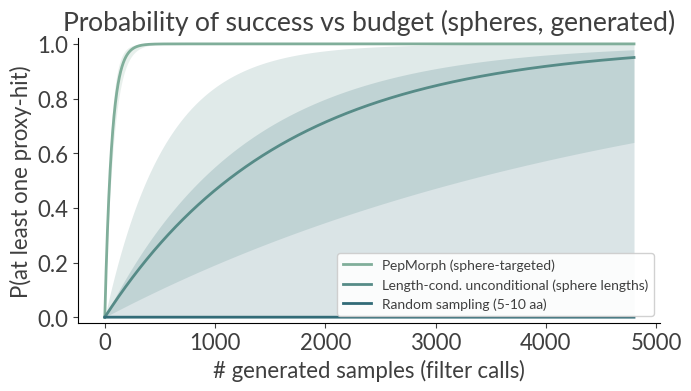

Wrote prob_hit_vs_budget_generated_spheres.svg


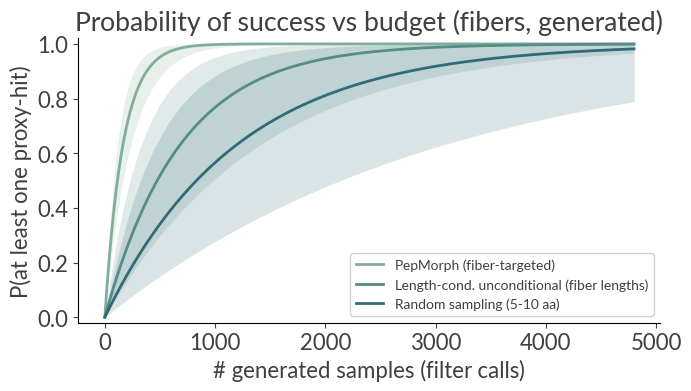

Wrote prob_hit_vs_budget_generated_fibers.svg


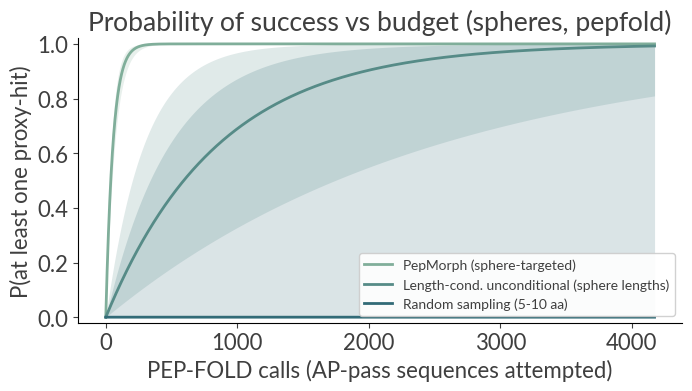

Wrote prob_hit_vs_budget_pepfold_spheres.svg


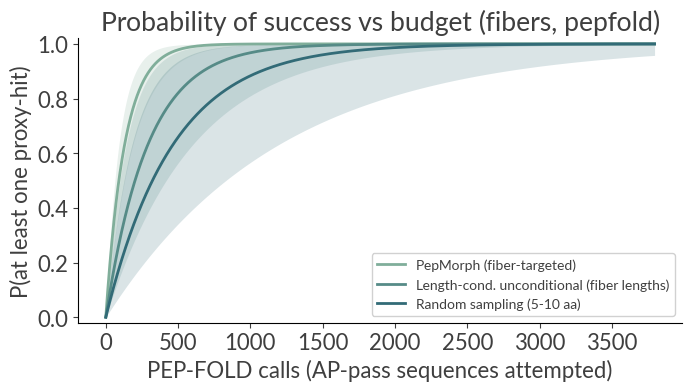

Wrote prob_hit_vs_budget_pepfold_fibers.svg


In [21]:
# %% [markdown]
# ## Plot: Probability of ≥1 proxy-hit vs budget
# We show both:
#   (A) budget = number of generated samples
#   (B) budget = number of PEP-FOLD calls (AP-pass sequences attempted)

# %%
def plot_prob_hit_vs_budget(df: pd.DataFrame,
                            target: str,
                            budget_kind: str,  # "generated" or "pepfold"
                            outfile: str,
                            cohort_order: list[str] | None = None,
                            max_budget: int | None = None):
    d = df[df["target"] == target].copy()
    if cohort_order is not None:
        d["cohort"] = pd.Categorical(d["cohort"], categories=cohort_order, ordered=True)
        d = d.sort_values("cohort")

    if budget_kind == "generated":
        # per-generated hit rate with Wilson CI
        p = d["hit_rate_gen"].to_numpy()
        plo = d["hit_rate_gen_ci_lo"].to_numpy()
        phi = d["hit_rate_gen_ci_hi"].to_numpy()
        budget_max = int(d["generated"].max()) if max_budget is None else int(max_budget)
        xlabel = "# generated samples (filter calls)"
    elif budget_kind == "pepfold":
        # per-PEP-FOLD-call hit rate with Wilson CI (already computed)
        p = d["hit_rate"].to_numpy()
        plo = d["hit_rate_ci_lo"].to_numpy()
        phi = d["hit_rate_ci_hi"].to_numpy()
        budget_max = int(d["ap_pass"].max()) if max_budget is None else int(max_budget)
        xlabel = "PEP-FOLD calls (AP-pass sequences attempted)"
    else:
        raise ValueError("budget_kind must be 'generated' or 'pepfold'")

    budgets = np.arange(0, budget_max + 1, dtype=int)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for i, row in d.reset_index(drop=True).iterrows():
        name = row["cohort"]
        y = prob_at_least_one_hit(p[i], budgets)
        ylo = prob_at_least_one_hit(plo[i], budgets)
        yhi = prob_at_least_one_hit(phi[i], budgets)

        color = TEAL[min(5, i+1)]  # distinct-ish
        ax.plot(budgets, y, label=name, linewidth=2.0, color=color)
        ax.fill_between(budgets, ylo, yhi, alpha=0.18, linewidth=0, color=color)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("P(at least one proxy-hit)")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Probability of success vs budget ({target}, {budget_kind})")

    _clean_axes(ax)
    ax.legend(loc="lower right", frameon=True, fancybox=True, framealpha=0.9, fontsize=10)
    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print("Wrote", outfile)

plot_prob_hit_vs_budget(df, "spheres", "generated", "prob_hit_vs_budget_generated_spheres.svg", cohort_order=ORDER_SPH)
plot_prob_hit_vs_budget(df, "fibers",  "generated", "prob_hit_vs_budget_generated_fibers.svg",  cohort_order=ORDER_FIB)

plot_prob_hit_vs_budget(df, "spheres", "pepfold", "prob_hit_vs_budget_pepfold_spheres.svg", cohort_order=ORDER_SPH)
plot_prob_hit_vs_budget(df, "fibers",  "pepfold", "prob_hit_vs_budget_pepfold_fibers.svg",  cohort_order=ORDER_FIB)

In [22]:
TARGETED = df[df["target"].isin(["spheres", "fibers"])].copy()

# keep only the cohorts you want (edit names)
KEEP = set(ORDER_SPH + ORDER_FIB)
TARGETED = TARGETED[TARGETED["cohort"].isin(KEEP)].copy()

cols = [
    "cohort","target","generated","ap_pass","pepfold_success","proxy_hits",
    "hit_rate_gen","hit_rate_gen_ci_lo","hit_rate_gen_ci_hi",
    "calls_per_hit_gen","calls_per_hit_gen_ci_lo","calls_per_hit_gen_ci_hi",
    "hit_rate","hit_rate_ci_lo","hit_rate_ci_hi",
    "calls_per_hit","calls_per_hit_ci_lo","calls_per_hit_ci_hi",
]
TARGETED = TARGETED[cols]
TARGETED.to_csv("efficiency_table_targeted.csv", index=False)
TARGETED

,cohort,target,generated,ap_pass,pepfold_success,proxy_hits,hit_rate_gen,hit_rate_gen_ci_lo,hit_rate_gen_ci_hi,calls_per_hit_gen,calls_per_hit_gen_ci_lo,calls_per_hit_gen_ci_hi,hit_rate,hit_rate_ci_lo,hit_rate_ci_hi,calls_per_hit,calls_per_hit_ci_lo,calls_per_hit_ci_hi
0,PepMorph (sphere-targeted),spheres,4800,4173,4173,76,0.015833,0.012669,0.019772,63.157895,50.577214,78.931041,0.018212,1.457599e-02,0.022735,54.907895,43.985281,6.860596e+01
1,PepMorph (fiber-targeted),fibers,4800,3794,3794,29,0.006042,0.004210,0.008663,165.517241,115.427963,237.532418,0.007644,5.327312e-03,0.010956,130.827586,91.273835,1.877119e+02
2,Random sampling (5-10 aa),spheres,4800,1863,1611,0,0.000000,0.000000,0.000800,inf,1250.479384,inf,0.000000,2.168404e-19,0.002058,inf,485.954186,4.611686e+18
3,Random sampling (5-10 aa),fibers,4800,1863,1611,4,0.000833,0.000324,0.002141,1200.000000,467.089108,3085.390892,0.002147,8.352489e-04,0.005508,465.750000,181.558356,1.197248e+03
5,Length-cond. unconditional (sphere lengths),spheres,4800,2566,2566,3,0.000625,0.000213,0.001836,1600.000000,544.627043,4704.226291,0.001169,3.976820e-04,0.003432,855.333333,291.377809,2.514572e+03
6,Length-cond. unconditional (fiber lengths),fibers,4800,2043,2043,7,0.001458,0.000707,0.003007,685.714286,332.509468,1415.239103,0.003426,1.660684e-03,0.007056,291.857143,141.724062,6.021614e+02


In [23]:
# --- SI table: targeted efficiency (generated-budget) with Wilson CI ---
def format_ci(lo, hi, fmt="{:.4f}"):
    return f"[{fmt.format(lo)}, {fmt.format(hi)}]"

def make_si_efficiency_table(df: pd.DataFrame, rows: list[tuple[str, str]]) -> pd.DataFrame:
    """
    rows: list of (cohort_name, target) pairs to include, in order.
    """
    out_rows = []
    for cohort, target in rows:
        r = df[(df["cohort"] == cohort) & (df["target"] == target)].iloc[0]
        out_rows.append(dict(
            Cohort=cohort,
            Target=target,
            Generated=int(r["generated"]),
            Hits=int(r["proxy_hits"]),
            HitRate=f'{r["hit_rate_gen"]:.4f} {format_ci(r["hit_rate_gen_ci_lo"], r["hit_rate_gen_ci_hi"])}',
            CallsPerHit=f'{r["calls_per_hit_gen"]:.1f} {format_ci(r["calls_per_hit_gen_ci_lo"], r["calls_per_hit_gen_ci_hi"], fmt="{:.1f}")}',
        ))
    return pd.DataFrame(out_rows)

si_rows = [
    ("PepMorph (sphere-targeted)", "spheres"),
    ("Length-cond. unconditional (sphere lengths)", "spheres"),
    ("Random sampling (5-10 aa)", "spheres"),
    ("PepMorph (fiber-targeted)", "fibers"),
    ("Length-cond. unconditional (fiber lengths)", "fibers"),
    ("Random sampling (5-10 aa)", "fibers"),
]

si_tbl = make_si_efficiency_table(df, si_rows)
si_tbl.to_csv("si_efficiency_table_generated_budget.csv", index=False)
si_tbl

,Cohort,Target,Generated,Hits,HitRate,CallsPerHit
0,PepMorph (sphere-targeted),spheres,4800,76,"0.0158 [0.0127, 0.0198]","63.2 [50.6, 78.9]"
1,Length-cond. unconditional (sphere lengths),spheres,4800,3,"0.0006 [0.0002, 0.0018]","1600.0 [544.6, 4704.2]"
2,Random sampling (5-10 aa),spheres,4800,0,"0.0000 [0.0000, 0.0008]","inf [1250.5, inf]"
3,PepMorph (fiber-targeted),fibers,4800,29,"0.0060 [0.0042, 0.0087]","165.5 [115.4, 237.5]"
4,Length-cond. unconditional (fiber lengths),fibers,4800,7,"0.0015 [0.0007, 0.0030]","685.7 [332.5, 1415.2]"
5,Random sampling (5-10 aa),fibers,4800,4,"0.0008 [0.0003, 0.0021]","1200.0 [467.1, 3085.4]"
